# Fixed-Point Iteration
> **Numerical Methods for Engineering** | Module 01 - Root Finding | `05_Fixed_Point.ipynb`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bpatinoa/numerical-methods-for-engineering/blob/main/01-Root-Finding/05_Fixed_Point.ipynb)

---

## Learning Objectives

After completing this notebook you will be able to:
- Reformulate $f(x)=0$ as a **fixed-point problem** $x = g(x)$ in multiple ways.
- State the **Banach Contraction Mapping Theorem** and apply it to guarantee convergence.
- Explain why $|g'(r)| < 1$ at the root determines convergence and rate.
- Use **cobweb diagrams** to visualise convergence and divergence geometrically.
- Demonstrate how Newton-Raphson is a special fixed-point iteration with $g'(r)=0$.
- Apply the method to problems in general mathematics, chemistry, and telecommunications.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize':(11,5),'font.size':12,
    'axes.grid':True,'grid.alpha':0.35,'lines.linewidth':2})
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Theoretical Background

### 1.1 From Root-Finding to Fixed-Point Problems

Any equation $f(x) = 0$ can be rewritten as a **fixed-point problem**:

$$x = g(x)$$

by algebraically rearranging $f$. A **fixed point** of $g$ is a value $r$ such that $g(r) = r$,
which is exactly a root of $f(x) = x - g(x) = 0$.

**Key insight:** there are infinitely many rearrangements $g$; the choice dramatically affects
whether the iteration $x_{n+1} = g(x_n)$ converges or diverges.

The algorithm is simply:

$$\boxed{x_{n+1} = g(x_n), \qquad n = 0, 1, 2, \ldots}$$

---

### 1.2 Banach Contraction Mapping Theorem

**Theorem** *(Banach, 1922)*: Let $g$ be continuous on $[a,b]$ with:
1. $g(x) \in [a,b]$ for all $x \in [a,b]$ (**self-mapping**)
2. $|g'(x)| \leq k < 1$ for all $x \in [a,b]$ (**contraction**)

Then $g$ has a **unique fixed point** $r \in [a,b]$, and the iteration $x_{n+1} = g(x_n)$
converges to $r$ for **any** starting point $x_0 \in [a,b]$.

**Error bound:**

$$|x_n - r| \leq \frac{k^n}{1-k}\,|x_1 - x_0|$$

---

### 1.3 Convergence Analysis

**Linear convergence.** Near the fixed point $r$, Taylor-expand $g$:

$$e_{n+1} = x_{n+1} - r = g(x_n) - g(r) = g'(\xi_n)\,(x_n - r) = g'(\xi_n)\,e_n$$

So:

$$\boxed{|e_{n+1}| \approx |g'(r)|\,|e_n|}$$

- If $|g'(r)| < 1$: **converges** (linear rate $= |g'(r)|$; smaller = faster)
- If $|g'(r)| = 1$: sublinear convergence (very slow)
- If $|g'(r)| > 1$: **diverges**
- If $|g'(r)| = 0$: **quadratic convergence** (Newton-Raphson case!)

---

### 1.4 Newton-Raphson as Fixed-Point Iteration

Newton-Raphson uses $g_\text{NR}(x) = x - f(x)/f'(x)$.

Its derivative at the root:

$$g'_\text{NR}(r) = 1 - \frac{f'(r)^2 - f(r)f''(r)}{f'(r)^2} = \frac{f(r)f''(r)}{f'(r)^2} = 0$$

since $f(r)=0$. This gives $|g'_\text{NR}(r)| = 0$ — the **optimal** fixed-point iteration,
achieving **quadratic convergence** as a special case of the general theory.

---

### 1.5 Cobweb Diagram

A **cobweb diagram** visualises the iteration by alternating between:
- Horizontal move: from $(x_n, x_n)$ to $(x_n, g(x_n))$
- Vertical move: from $(x_n, g(x_n))$ to $(g(x_n), g(x_n))$

Convergence appears as a spiral inward; divergence as a spiral outward.

---

### 1.6 Pseudocode

```
INPUT:  g, x0, tol, max_iter

FOR i = 1 TO max_iter:
    x1  <-  g(x0)
    IF |x1 - x0| / max(|x1|, 1)  <  tol:
        RETURN x1        -- converged
    x0  <-  x1
END FOR
RETURN x1                -- best approximation
```

---

### 1.7 Advantages and Limitations

| Advantages | Limitations |
|------------|-------------|
| Extremely simple to implement | Convergence **not guaranteed** without contraction condition |
| Connects root-finding to general iteration theory | Rate only linear ($|g'(r)|$) in general |
| Flexible: many rearrangements possible | Choice of $g$ is problem-dependent and non-trivial |
| Foundation for Newton, Gauss-Seidel, power iteration | Diverges if $|g'(x_0)| > 1$ |


In [2]:
def fixed_point(g, x0, tol=1e-10, max_iter=200, verbose=False):
    # Fixed-Point Iteration: solve x = g(x) starting from x0.
    hist = {'iterates':[x0], 'errors':[], 'g_values':[g(x0)]}
    if verbose:
        print(f"{'n':>4}  {'x_n':>18}  {'g(x_n)':>18}  {'|step|':>12}")
        print('-'*60)
    x = x0
    for i in range(1, max_iter+1):
        x_new = g(x)
        step  = abs(x_new - x)
        rel   = step / max(abs(x_new), 1.0)
        hist['iterates'].append(x_new)
        hist['errors'].append(step)
        hist['g_values'].append(g(x_new))
        if verbose:
            print(f'{i:>4}  {x_new:>18.12f}  {g(x_new):>18.12f}  {step:>12.4e}')
        if rel < tol:
            break
        if abs(x_new) > 1e10:
            raise OverflowError(f'Diverging at iter {i}: x={x_new:.3e}')
        x = x_new
    return x_new, hist


def cobweb(g, x0, n_iters, x_range, ax, title='', color='crimson'):
    # Draw cobweb diagram on ax.
    x_vals = np.linspace(x_range[0], x_range[1], 500)
    ax.plot(x_vals, g(x_vals), color='steelblue', lw=2, label='y = g(x)')
    ax.plot(x_vals, x_vals,    color='k',         lw=1, ls='--', label='y = x')
    # Cobweb path
    x = x0
    for _ in range(n_iters):
        gx = g(x)
        ax.plot([x, x],   [x, gx], color=color, lw=1, alpha=0.7)
        ax.plot([x, gx],  [gx,gx], color=color, lw=1, alpha=0.7)
        x = gx
    ax.set(xlabel='x', ylabel='g(x)', title=title)
    ax.legend(fontsize=9)

---
## 2. Examples

### 2.1 General Mathematical Example - Effect of Rearrangement Choice

Find the root of $f(x) = x^3 + x - 1$. True root: $r \approx 0.6824$.

Three different rearrangements of $f(x)=0$:

| Rearrangement | $g(x)$ | $g'(x)$ | $\|g'(r)\|$ | Behaviour |
|---------------|---------|---------|------------|-----------|
| $x = 1 - x^3$ | $g_1(x) = 1-x^3$ | $-3x^2$ | $1.40$ | **Diverges** |
| $x^3 = 1-x \implies x=(1-x)^{1/3}$ | $g_2(x) = (1-x)^{1/3}$ | $-\tfrac{1}{3}(1-x)^{-2/3}$ | $0.72$ | **Converges** |
| Newton-Raphson | $g_3(x) = x - \tfrac{x^3+x-1}{3x^2+1}$ | $\tfrac{3x^2(3x^2+1)-(x^3+x-1)\cdot 6x}{(3x^2+1)^2}$ | $0$ | **Quadratic** |


In [3]:
f_poly  = lambda x: x**3 + x - 1
df_poly = lambda x: 3*x**2 + 1
r_exact = 0.6823278038280193   # high-precision fixed point

g1 = lambda x: 1 - x**3                                    # diverges
g2 = lambda x: (1 - x)**(1/3)                              # converges
g3 = lambda x: x - f_poly(x)/df_poly(x)                    # Newton-Raphson

# Verify contraction conditions at r
dg1_r = abs(-3 * r_exact**2)
dg2_r = abs(-1/(3*(1-r_exact)**(2/3)))
print(f'|g1\' (r)| = {dg1_r:.4f}  --> {"DIVERGES" if dg1_r>1 else "converges"}')
print(f'|g2\' (r)| = {dg2_r:.4f}  --> {"DIVERGES" if dg2_r>1 else "converges"}')
print(f'|g3\' (r)| = 0.0000  --> Newton-Raphson (quadratic convergence)')
print()

# Run g2 and g3 (g1 diverges)
root2, h2 = fixed_point(g2, x0=0.5, tol=1e-12, verbose=True)
print(f'g2 root: {root2:.14f}  err={abs(root2-r_exact):.2e}')
print()
root3, h3 = fixed_point(g3, x0=0.5, tol=1e-14, verbose=True)
print(f'g3 root: {root3:.14f}  err={abs(root3-r_exact):.2e}')

# Attempt g1 (show divergence)
x_div = 0.5
g1_iterates = [x_div]
for _ in range(8):
    x_div = g1(x_div)
    g1_iterates.append(x_div)
    if abs(x_div) > 1e6: break
print(f'g1 iterates: {[round(v,4) for v in g1_iterates[:6]]} ... (diverges)')

|g1' (r)| = 1.3967  --> DIVERGES
|g2' (r)| = 0.7160  --> converges
|g3' (r)| = 0.0000  --> Newton-Raphson (quadratic convergence)

   n                 x_n              g(x_n)        |step|
------------------------------------------------------------
   1      0.793700525984      0.590880113275    2.9370e-01
   2      0.590880113275      0.742363932168    2.0282e-01
   3      0.742363932168      0.636310203482    1.5148e-01
   4      0.636310203482      0.713800814144    1.0605e-01
   5      0.713800814144      0.659006145622    7.7491e-02
   6      0.659006145622      0.698632605730    5.4795e-02
   7      0.698632605730      0.670448496228    3.9626e-02
   8      0.670448496228      0.690729120589    2.8184e-02
   9      0.690729120589      0.676258924927    2.0281e-02
  10      0.676258924927      0.686645536864    1.4470e-02
  11      0.686645536864      0.679222339897    1.0387e-02
  12      0.679222339897      0.684544005470    7.4232e-03
  13      0.684544005470      0.680737373

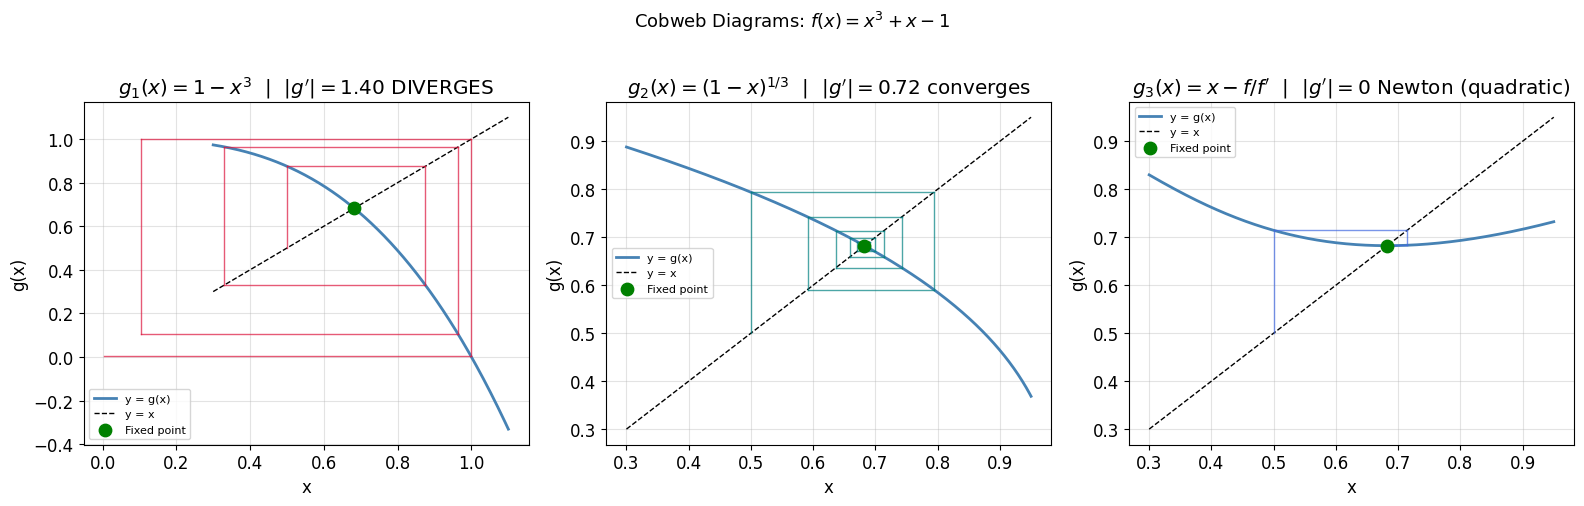

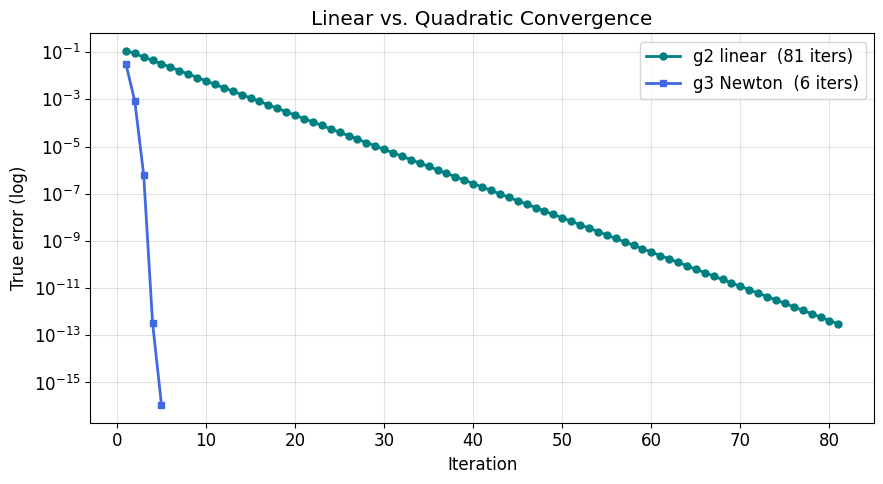

In [4]:
# Cobweb diagrams for the three rearrangements
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cobweb(g1, x0=0.5, n_iters=6, x_range=[0.3, 1.1], ax=axes[0],
       title="$g_1(x)=1-x^3$  |  $|g'|=1.40$ DIVERGES", color='crimson')
axes[0].scatter([r_exact],[r_exact], color='green', s=80, zorder=5, label='Fixed point')
axes[0].legend(fontsize=8)

cobweb(g2, x0=0.5, n_iters=12, x_range=[0.3, 0.95], ax=axes[1],
       title="$g_2(x)=(1-x)^{1/3}$  |  $|g'|=0.72$ converges", color='teal')
axes[1].scatter([r_exact],[r_exact], color='green', s=80, zorder=5, label='Fixed point')
axes[1].legend(fontsize=8)

cobweb(g3, x0=0.5, n_iters=5, x_range=[0.3, 0.95], ax=axes[2],
       title="$g_3(x)=x-f/f'$  |  $|g'|=0$ Newton (quadratic)", color='royalblue')
axes[2].scatter([r_exact],[r_exact], color='green', s=80, zorder=5, label='Fixed point')
axes[2].legend(fontsize=8)

plt.suptitle(r'Cobweb Diagrams: $f(x)=x^3+x-1$', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/sessions/epic-eloquent-mccarthy/mnt/outputs/fp_cobweb.png', dpi=120, bbox_inches='tight')
plt.show()

# Convergence comparison
fig, ax = plt.subplots(figsize=(9,5))
e2 = [abs(x-r_exact) for x in h2['iterates'][1:] if abs(x-r_exact)>1e-16]
e3 = [abs(x-r_exact) for x in h3['iterates'][1:] if abs(x-r_exact)>1e-16]
ax.semilogy(range(1,len(e2)+1), e2, 'o-', color='teal',      ms=5, label=f'g2 linear  ({len(h2["errors"])} iters)')
ax.semilogy(range(1,len(e3)+1), e3, 's-', color='royalblue', ms=5, label=f'g3 Newton  ({len(h3["errors"])} iters)')
ax.set(xlabel='Iteration', ylabel='True error (log)', title='Linear vs. Quadratic Convergence')
ax.legend()
plt.tight_layout()
plt.savefig('/sessions/epic-eloquent-mccarthy/mnt/outputs/fp_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.2 Chemistry Application - Successive Substitution for Weak Acid Equilibrium

**Background:** For a weak acid HA with $K_a$ and initial concentration $C$, the equilibrium:

$$K_a = \frac{x^2}{C - x} \implies x^2 + K_a x - K_a C = 0$$

**Fixed-point rearrangement** (successive substitution):

$$x = g(x) = \sqrt{K_a(C - x)}$$

**Convergence check:**

$$g'(x) = -\frac{K_a}{2\sqrt{K_a(C-x)}} = -\frac{K_a}{2x^*}$$

At the root $x^* \approx 1.33\times10^{-3}$ mol/L:
$|g'(x^*)| = 1.8\times10^{-5}/(2\times1.33\times10^{-3}) \approx 0.0068 \ll 1$ -- fast convergence!

**Starting guess:** $x_0 = K_a$ (zeroth-order approximation, assuming $x \ll C$).

**Case study:** Acetic acid, $K_a = 1.8\times10^{-5}$ mol/L, $C = 0.10$ mol/L.


Contraction constant |g' (x*)| = 0.006753  << 1  --> fast convergence
Starting guess x0 = Ka = 1.80e-05 mol/L

   n                 x_n              g(x_n)        |step|
------------------------------------------------------------
   1      0.001341520033      0.001332611211    1.3235e-03
   2      0.001332611211      0.001332671377    8.9088e-06
   3      0.001332671377      0.001332670970    6.0166e-08
   4      0.001332670970      0.001332670973    4.0632e-10
   5      0.001332670973      0.001332670973    2.7440e-12
   6      0.001332670973      0.001332670973    1.8531e-14
   7      0.001332670973      0.001332670973    1.2512e-16

Result (FP iteration)  : [H+] = 1.3326709731e-03 mol/L
Result (analytical)    : [H+] = 1.3326709731e-03 mol/L
Absolute error         : 8.67e-19 mol/L
pH (FP iteration)      : 2.875277
pH (analytical)        : 2.875277
Iterations             : 7


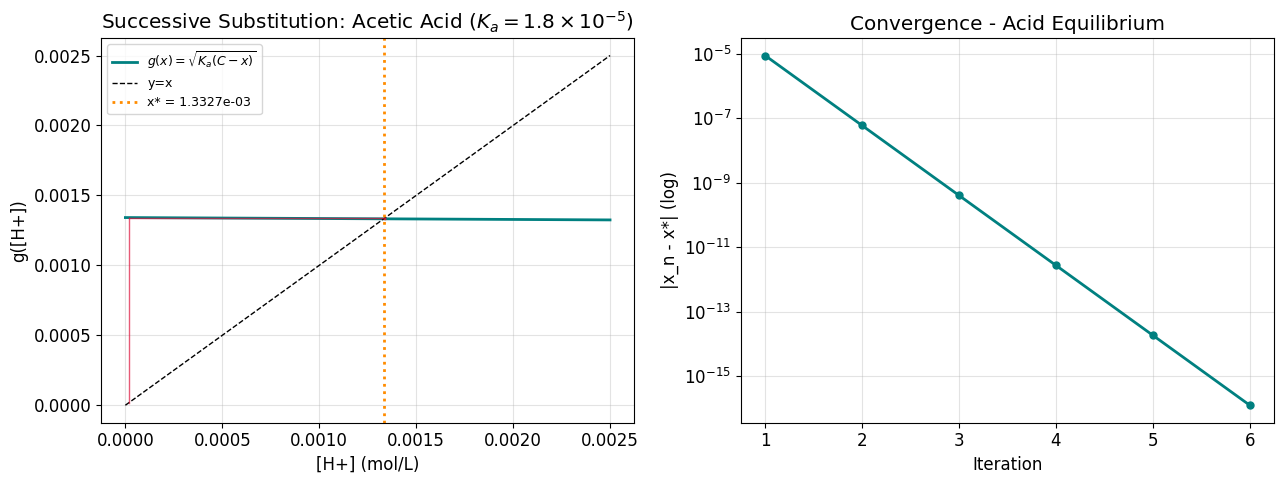

In [5]:
Ka = 1.8e-5
C  = 0.10

# Successive substitution: x = sqrt(Ka*(C - x))
g_acid = lambda x: np.sqrt(Ka * (C - x))

# Analytical solution (quadratic formula) as reference
x_exact = (-Ka + np.sqrt(Ka**2 + 4*Ka*C)) / 2

# Contraction constant at root
k_contract = Ka / (2 * x_exact)
print(f'Contraction constant |g\' (x*)| = {k_contract:.6f}  << 1  --> fast convergence')
print(f'Starting guess x0 = Ka = {Ka:.2e} mol/L')
print()

root_acid, h_acid = fixed_point(g_acid, x0=Ka, tol=1e-14, verbose=True)

print(f'\nResult (FP iteration)  : [H+] = {root_acid:.10e} mol/L')
print(f'Result (analytical)    : [H+] = {x_exact:.10e} mol/L')
print(f'Absolute error         : {abs(root_acid - x_exact):.2e} mol/L')
print(f'pH (FP iteration)      : {-np.log10(root_acid):.6f}')
print(f'pH (analytical)        : {-np.log10(x_exact):.6f}')
print(f'Iterations             : {len(h_acid["errors"])}')

# Plot convergence toward x*
iters_vals = h_acid['iterates']
fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
x_range = np.linspace(0, 0.0025, 400)
g_vals  = g_acid(x_range)
ax.plot(x_range, g_vals,   color='teal',     lw=2, label=r'$g(x)=\sqrt{K_a(C-x)}$')
ax.plot(x_range, x_range,  color='k',        lw=1, ls='--', label='y=x')
ax.axvline(root_acid, color='darkorange', ls=':', lw=2, label=f'x* = {root_acid:.4e}')
# Cobweb (few steps for clarity)
x = Ka
for _ in range(6):
    gx = g_acid(x)
    ax.plot([x,x],[x,gx], color='crimson', lw=1, alpha=0.7)
    ax.plot([x,gx],[gx,gx], color='crimson', lw=1, alpha=0.7)
    x=gx
ax.set(xlabel='[H+] (mol/L)', ylabel='g([H+])',
       title=r'Successive Substitution: Acetic Acid ($K_a=1.8\times10^{-5}$)')
ax.legend(fontsize=9)

ax = axes[1]
true_errs = [abs(v - x_exact) for v in iters_vals[1:] if abs(v-x_exact)>1e-18]
ax.semilogy(range(1,len(true_errs)+1), true_errs, 'o-', color='teal', ms=5)
ax.set(xlabel='Iteration', ylabel='|x_n - x*| (log)', title='Convergence - Acid Equilibrium')

plt.tight_layout()
plt.savefig('/sessions/epic-eloquent-mccarthy/mnt/outputs/fp_chem.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3 Telecommunications Application - Diode Detector Operating Point

**Background:** In AM demodulators and RF power detectors, a diode is biased by a DC source
$V_s$ through a resistor $R$. The Shockley equation governs the diode current:

$$I = I_s\!\left(e^{V_D/(n V_T)} - 1\right)$$

KCL gives: $I = (V_s - V_D)/R$. Eliminating $I$:

$$V_D = n V_T \ln\!\left(\frac{V_s - V_D}{R\,I_s} + 1\right) = g(V_D)$$

**Convergence condition:**

$$g'(V_D) = -\frac{n V_T}{V_s - V_D + R\,I_s} \approx -\frac{n V_T}{R\,I^*}$$

For $I^* \approx 10$ mA: $|g'| = 0.02585/(100\times0.01) = 0.026 \ll 1$ -- fast convergence.

| Parameter | Value | Description |
|-----------|-------|-------------|
| $I_s$ | $10^{-9}$ A | Reverse saturation current (silicon RF diode) |
| $n$ | 1 | Ideality factor |
| $V_T$ | 0.02585 V | Thermal voltage at $T=300$ K |
| $R$ | 100 $\Omega$ | Load resistance |
| $V_s$ | 2.0 V | Supply voltage |


Approx. operating point: VD ~ 0.43 V, I ~ 15.7 mA
Contraction constant   : |g' | ~ 0.0165  << 1

   n                 x_n              g(x_n)        |step|
------------------------------------------------------------
   1      0.425350581740      0.428389518374    1.7465e-01
   2      0.428389518374      0.428339581920    3.0389e-03
   3      0.428339581920      0.428340403267    4.9936e-05
   4      0.428340403267      0.428340389758    8.2135e-07
   5      0.428340389758      0.428340389980    1.3509e-08
   6      0.428340389980      0.428340389976    2.2219e-10
   7      0.428340389976      0.428340389976    3.6545e-12
   8      0.428340389976      0.428340389976    6.0063e-14

Operating point VD   = 0.42834039 V
Load current   I     = 15.716596 mA  (from Ohm's law)
Diode current  I     = 15.716596 mA  (from Shockley eq.)
KCL error            = 5.93e-16 A  (should be ~0)
Iterations           = 8


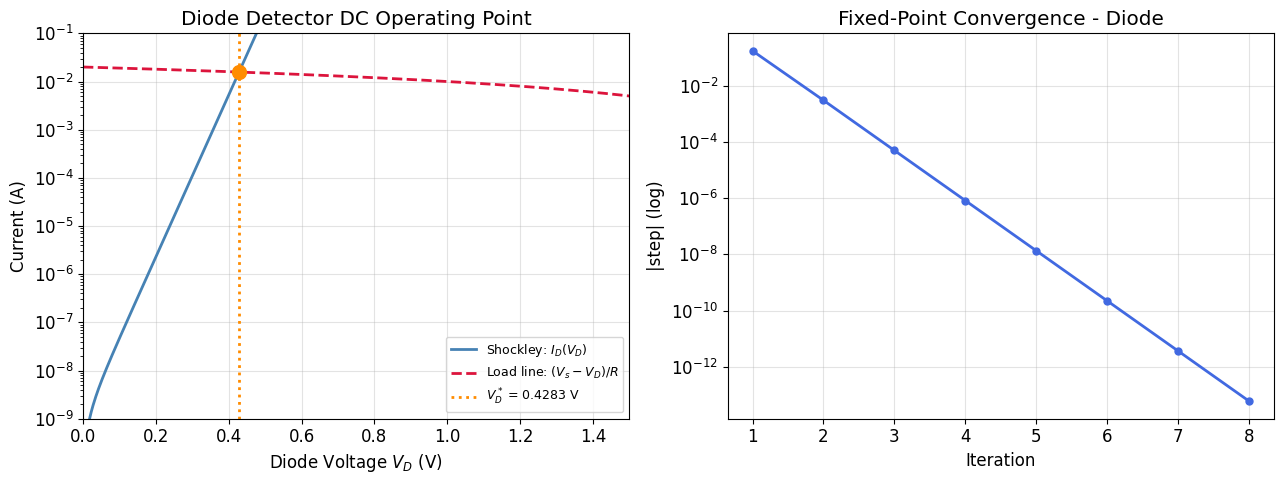

In [6]:
Is  = 1e-9     # A  (reverse saturation current)
n   = 1.0      # ideality factor
VT  = 0.02585  # V  (thermal voltage at 300 K)
R   = 100.0    # Ohm (load resistance)
Vs  = 2.0      # V  (supply voltage)

# Fixed-point form: VD = n*VT * ln((Vs - VD)/(R*Is) + 1)
g_diode = lambda VD: n * VT * np.log((Vs - VD)/(R * Is) + 1)

# Check contraction at expected operating point (~0.43 V)
VD_approx = 0.43
I_approx  = (Vs - VD_approx) / R
k_diode   = abs(n * VT / (Vs - VD_approx + R*Is))
print(f'Approx. operating point: VD ~ {VD_approx} V, I ~ {I_approx*1e3:.1f} mA')
print(f'Contraction constant   : |g\' | ~ {k_diode:.4f}  << 1')
print()

# Starting guess: ideal diode drop for silicon
x0_diode = 0.6
root_diode, h_diode = fixed_point(g_diode, x0=x0_diode, tol=1e-12, verbose=True)

I_op  = (Vs - root_diode) / R
I_sh  = Is * (np.exp(root_diode/(n*VT)) - 1)
print(f'\nOperating point VD   = {root_diode:.8f} V')
print(f'Load current   I     = {I_op*1e3:.6f} mA  (from Ohm\'s law)')
print(f'Diode current  I     = {I_sh*1e3:.6f} mA  (from Shockley eq.)')
print(f'KCL error            = {abs(I_op-I_sh):.2e} A  (should be ~0)')
print(f'Iterations           = {len(h_diode["errors"])}')

# Plot: load line and diode curve
VD_range = np.linspace(0, 1.5, 600)
I_diode  = Is*(np.exp(VD_range/(n*VT))-1)
I_load   = (Vs - VD_range)/R

fig, axes = plt.subplots(1, 2, figsize=(13,5))

ax = axes[0]
ax.semilogy(VD_range, I_diode, color='steelblue', label='Shockley: $I_D(V_D)$')
ax.semilogy(VD_range[I_load>1e-12], I_load[I_load>1e-12],
            color='crimson', ls='--', label=f'Load line: $(V_s-V_D)/R$')
ax.axvline(root_diode, color='darkorange', ls=':', lw=2,
           label=f'$V_D^*$ = {root_diode:.4f} V')
ax.scatter([root_diode], [I_op], color='darkorange', s=100, zorder=5)
ax.set(xlabel='Diode Voltage $V_D$ (V)', ylabel='Current (A)',
       ylim=(1e-9, 1e-1), xlim=(0, 1.5),
       title='Diode Detector DC Operating Point')
ax.legend(fontsize=9)

ax = axes[1]
errs_d = h_diode['errors']
ax.semilogy(range(1,len(errs_d)+1), errs_d, 'o-', color='royalblue', ms=5)
ax.set(xlabel='Iteration', ylabel='|step| (log)', title='Fixed-Point Convergence - Diode')

plt.tight_layout()
plt.savefig('/sessions/epic-eloquent-mccarthy/mnt/outputs/fp_telecom.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Convergence Rate Summary

The table below consolidates the contraction constants and iteration counts from all examples,
confirming that $|g'(r)|$ controls the convergence speed.


In [7]:
print('{:<32} {:>10} {:>8} {:<12}'.format('Example', "|g'(r)|", 'Iters', 'Rate'))
print('-'*68)

rows = [
    ('g2: x=(1-x)^(1/3)   [general]', abs(-1/(3*(1-r_exact)**(2/3))), len(h2['errors']),   'Linear'),
    ('g3: Newton-Raphson   [general]', 0.0,                            len(h3['errors']),   'Quadratic'),
    ('g:  acid equilibrium [chem]',    Ka/(2*x_exact),                 len(h_acid['errors']),'Linear'),
    ('g:  diode equation   [telecom]', k_diode,                        len(h_diode['errors']),'Linear'),
]

r_exact = 0.6823278038280193
x_exact_acid = (-Ka + np.sqrt(Ka**2 + 4*Ka*C)) / 2

rows = [
    ('g2: x=(1-x)^(1/3)  [general]',  abs(-1/(3*(1-r_exact)**(2/3))), len(h2['errors']),   'Linear'),
    ('g3: Newton-Raphson  [general]',   0.0,                            len(h3['errors']),   'Quadratic'),
    ('g:  acid equilibrium [chem]',     Ka/(2*x_exact_acid),            len(h_acid['errors']),'Linear'),
    ('g:  diode equation  [telecom]',   k_diode,                        len(h_diode['errors']),'Linear'),
]
for name, k, n_it, rate in rows:
    print(f"  {name:<30} {k:>10.4f} {n_it:>8d} {rate:<12}")

Example                             |g'(r)|    Iters Rate        
--------------------------------------------------------------------
  g2: x=(1-x)^(1/3)  [general]       0.7160       81 Linear      
  g3: Newton-Raphson  [general]      0.0000        6 Quadratic   
  g:  acid equilibrium [chem]        0.0068        7 Linear      
  g:  diode equation  [telecom]      0.0165        8 Linear      


---
## 4. Student Exercises

---

**Exercise 1 - Rearrangement exploration**
For $f(x) = x^2 - 2$ (root $r = \sqrt{2}$):
a) Show that $g_1(x) = 2/x$ has $|g_1'(r)| = 1$ — predict the convergence behaviour and verify.
b) Show that $g_2(x) = (x + 2/x)/2$ is Newton-Raphson — what is $g_2'(r)$?
c) Implement both and compare. What does the cobweb for $g_1$ look like?

---

**Exercise 2 - Banach Theorem verification**
For $g(x) = \cos(x)$ on $[0, 1]$:
a) Verify that $g$ maps $[0,1]$ to $[0,1]$ (self-mapping condition).
b) Compute $\max_{x\in[0,1]}|g'(x)|$ and verify the contraction condition.
c) Run the iteration from $x_0 = 0.5$ and verify it converges to the Dottie number $r \approx 0.73909$.

---

**Exercise 3 - Electrochemical equilibrium (Chemistry)**
The Nernst equation for the electrode potential of a concentration cell is:
$$E = E^\circ - \frac{RT}{nF}\ln Q$$
where $Q = [\text{products}]/[\text{reactants}]$ depends on concentration $c$ through a mass
balance. Set up and solve a fixed-point iteration for $c$ at equilibrium.
Use $E^\circ = 0.34$ V, $n=2$, $T=298$ K, $F=96485$ C/mol.

---

**Exercise 4 - Antenna current distribution (Telecom)**
The current on a centre-fed dipole satisfies the integral equation:
$$I(z) = \frac{V_0}{Z_{in}}\,\sin(k(L-|z|))$$
where $Z_{in}$ itself depends on the current distribution (through the radiation integral).
Reformulate as a fixed-point problem and apply one iteration starting from the sinusoidal guess.

---

**Exercise 5 - Steffensen's Method**
**Steffensen's method** accelerates fixed-point iteration using Aitken's $\Delta^2$ trick:

$$x_{n+1} = x_n - \frac{(g(x_n)-x_n)^2}{g(g(x_n)) - 2g(x_n) + x_n}$$

It achieves **quadratic convergence** without a derivative.
a) Implement Steffensen's method.
b) Compare its iteration count against standard fixed-point and Newton-Raphson on $f(x)=x^3+x-1$.


---
## 5. References

1. **Chapra, S. C., & Canale, R. P.** (2015). *Numerical Methods for Engineers* (7th ed., pp. 152-165).
   McGraw-Hill Education.
   *Chapter 6 introduces fixed-point iteration. Section 6.2 proves the convergence condition
   $|g'(r)|<1$ and presents the cobweb diagram interpretation used throughout this notebook.*

2. **Burden, R. L., Faires, J. D., & Burden, A. M.** (2016). *Numerical Analysis* (10th ed., pp. 57-67).
   Cengage Learning.
   *Theorem 2.3 (Fixed-Point Theorem) and Theorem 2.4 (contraction mapping) are the rigorous
   basis for the Banach discussion in Section 1.2. Corollary 2.5 gives the a priori error bound.*

3. **Cheney, W., & Kincaid, D.** (2012). *Numerical Mathematics and Computing* (7th ed., pp. 95-112).
   Brooks/Cole.
   *Section 3.2 analyses multiple rearrangements of the same equation (as in Example 2.1) and
   derives the convergence rate formula $|e_{n+1}|\approx|g'(r)|\,|e_n|$ in Section 1.3.*

4. **Kreyszig, E.** (1978). *Introductory Functional Analysis with Applications* (pp. 299-308).
   John Wiley & Sons.
   *Chapter 5 presents the Banach Fixed-Point Theorem in its full generality in metric spaces,
   providing the mathematical foundation for the engineering convergence conditions in Section 1.2.*

5. **Razavi, B.** (2012). *RF Microelectronics* (2nd ed., pp. 51-68). Pearson.
   *Section 2.2 derives the Shockley diode model and its small-signal parameters at the DC
   operating point, the physical basis of the fixed-point formulation in Example 2.3.*
